In [ ]:
from google.colab import drive
import os
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers, optimizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    LearningRateScheduler,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam, AdamW

from keras.models import Sequential, load_model
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
    Rescaling
)


In [ ]:
### random seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

In [ ]:


drive.mount('/content/drive')
folder = '/content/drive/MyDrive/train_val'
folder_models = '/content/drive/MyDrive/my_models/'
your_model_folder = '/content/drive/MyDrive/my_models/'

os.makedirs(folder_models, exist_ok=True)

image_paths =[]


for path in os.listdir(folder):
  image_paths.append(os.path.join(folder,path))

Mounted at /content/drive


#Preprocessing

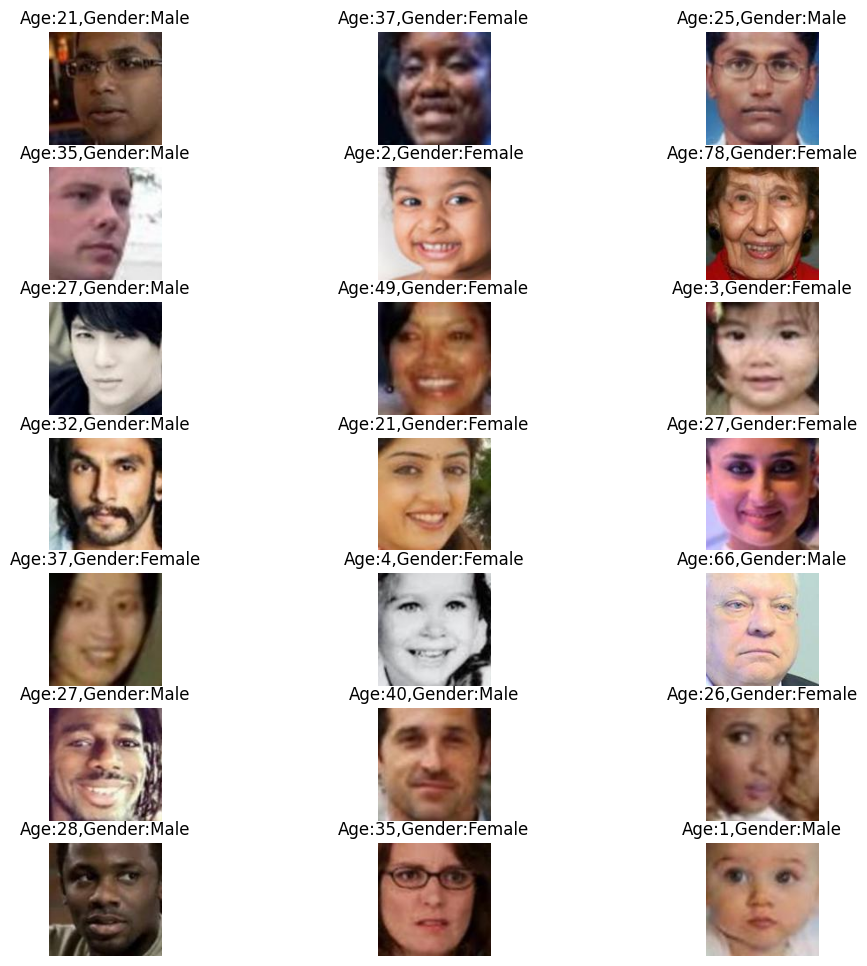

In [ ]:

all_image_files = [file for file in os.listdir(folder) if file.lower().endswith(('.jpg'))]

plt.figure(figsize=(12,12))
for i, image_file in enumerate(all_image_files[:21]):

    ###get age ad gender from image files
    info  =  image_file.split('_')
    age =info[0]
    gender=info[1]
    if gender =='0':
      gender = 'Male'
    else:
      gender ='Female'

    path= os.path.join(folder,image_file)
    img = Image.open(path)

    plt.subplot(7,3,i+1)
    plt.imshow(img)
    plt.title(f"Age:{age},Gender:{gender}")
    plt.axis('off')

plt.show()

Number of images for training: 4000
Number of images for validation: 1000
load all image data, age and gender labels...
load all image data, age and gender labels...


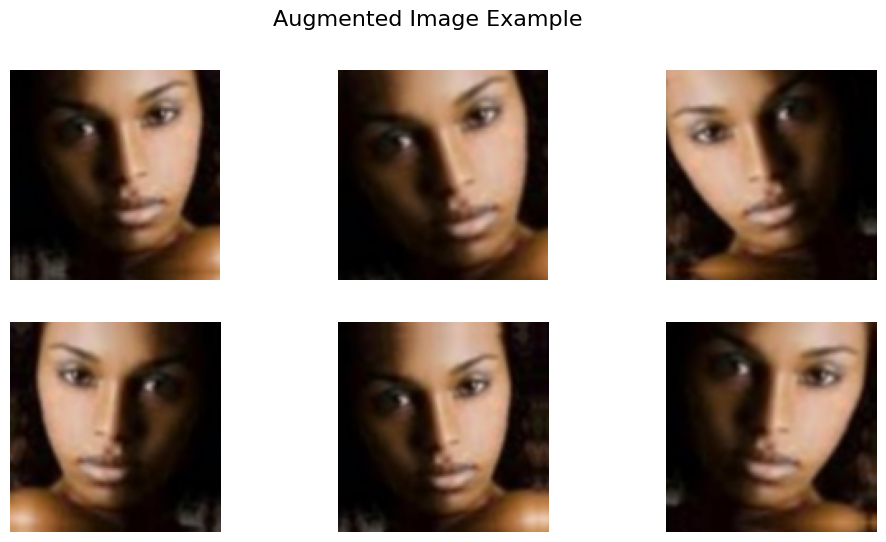

In [ ]:


folder_train_val = folder
all_image_files = [file for file in os.listdir(folder_train_val) if file.lower().endswith(('.jpg'))]

# Shuffle the dataset to ensure random distribution
random.seed(0)  # Ensure reproducibility
random.shuffle(all_image_files)

# Calculate the number of images for each set
n_train_val = len(all_image_files)
train_end = int(n_train_val * 0.8)

# Split the dataset
train_image_files = all_image_files[:train_end]
val_image_files = all_image_files[train_end:]
print(f"Number of images for training: {len(train_image_files)}")
print(f"Number of images for validation: {len(val_image_files)}")

def load_imgs_lables(dataset_path,filenames):
  print('load all image data, age and gender labels...')
  images = []
  age_labels = []
  gender_labels = []
  for current_file_name in filenames:
    img = cv2.imread(os.path.join(dataset_path, current_file_name))
    img = img / 255.0  # Normalize pixel values
    labels = current_file_name.split('_')
    age_label = int(labels[0])
    gender_label = int(labels[1])
    age_labels.append(age_label)
    gender_labels.append(gender_label)
    images.append(img)

  # Convert to NumPy arrays
  images = np.array(images)
  age_labels = np.array(age_labels)
  gender_labels = np.array(gender_labels)
  return images, age_labels, gender_labels

# load data from the training set
train_images, train_age, train_gender = load_imgs_lables(folder_train_val,train_image_files)

# load data from the validation set
val_images, val_age, val_gender = load_imgs_lables(folder_train_val,val_image_files)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),        ### random horizontal flips
    layers.RandomRotation(0.05),            ### small random rotations
    layers.RandomZoom(0.1),                 ### zoom in/out
    layers.RandomTranslation(0.05, 0.05),   ### random horizontal and verticl shifts
], name='data_augmentation')





def show_augmented_images(sample_image,augmentation_layer):
    plt.figure(figsize=(12, 6))
    for i in range(6):
        augmented = augmentation_layer(tf.expand_dims(sample_image, axis=0))[0]
        plt.subplot(2, 3, i + 1)
        plt.imshow(augmented)   #
        plt.axis('off')

    plt.suptitle('Augmented Image Example', fontsize=16)
    plt.show()



example_path = os.path.join(folder_train_val, all_image_files[0])
example_image = np.array(Image.open(example_path)) / 255.0
show_augmented_images(example_image, data_augmentation)


#Model A - CNN from Scratch

Model: "modelA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ data_augmentatio… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 2,293,954 (8.75 MB)

 Trainable params: 2,293,026 (8.75 MB)

 Non-trainable params: 928 (3.62 KB)

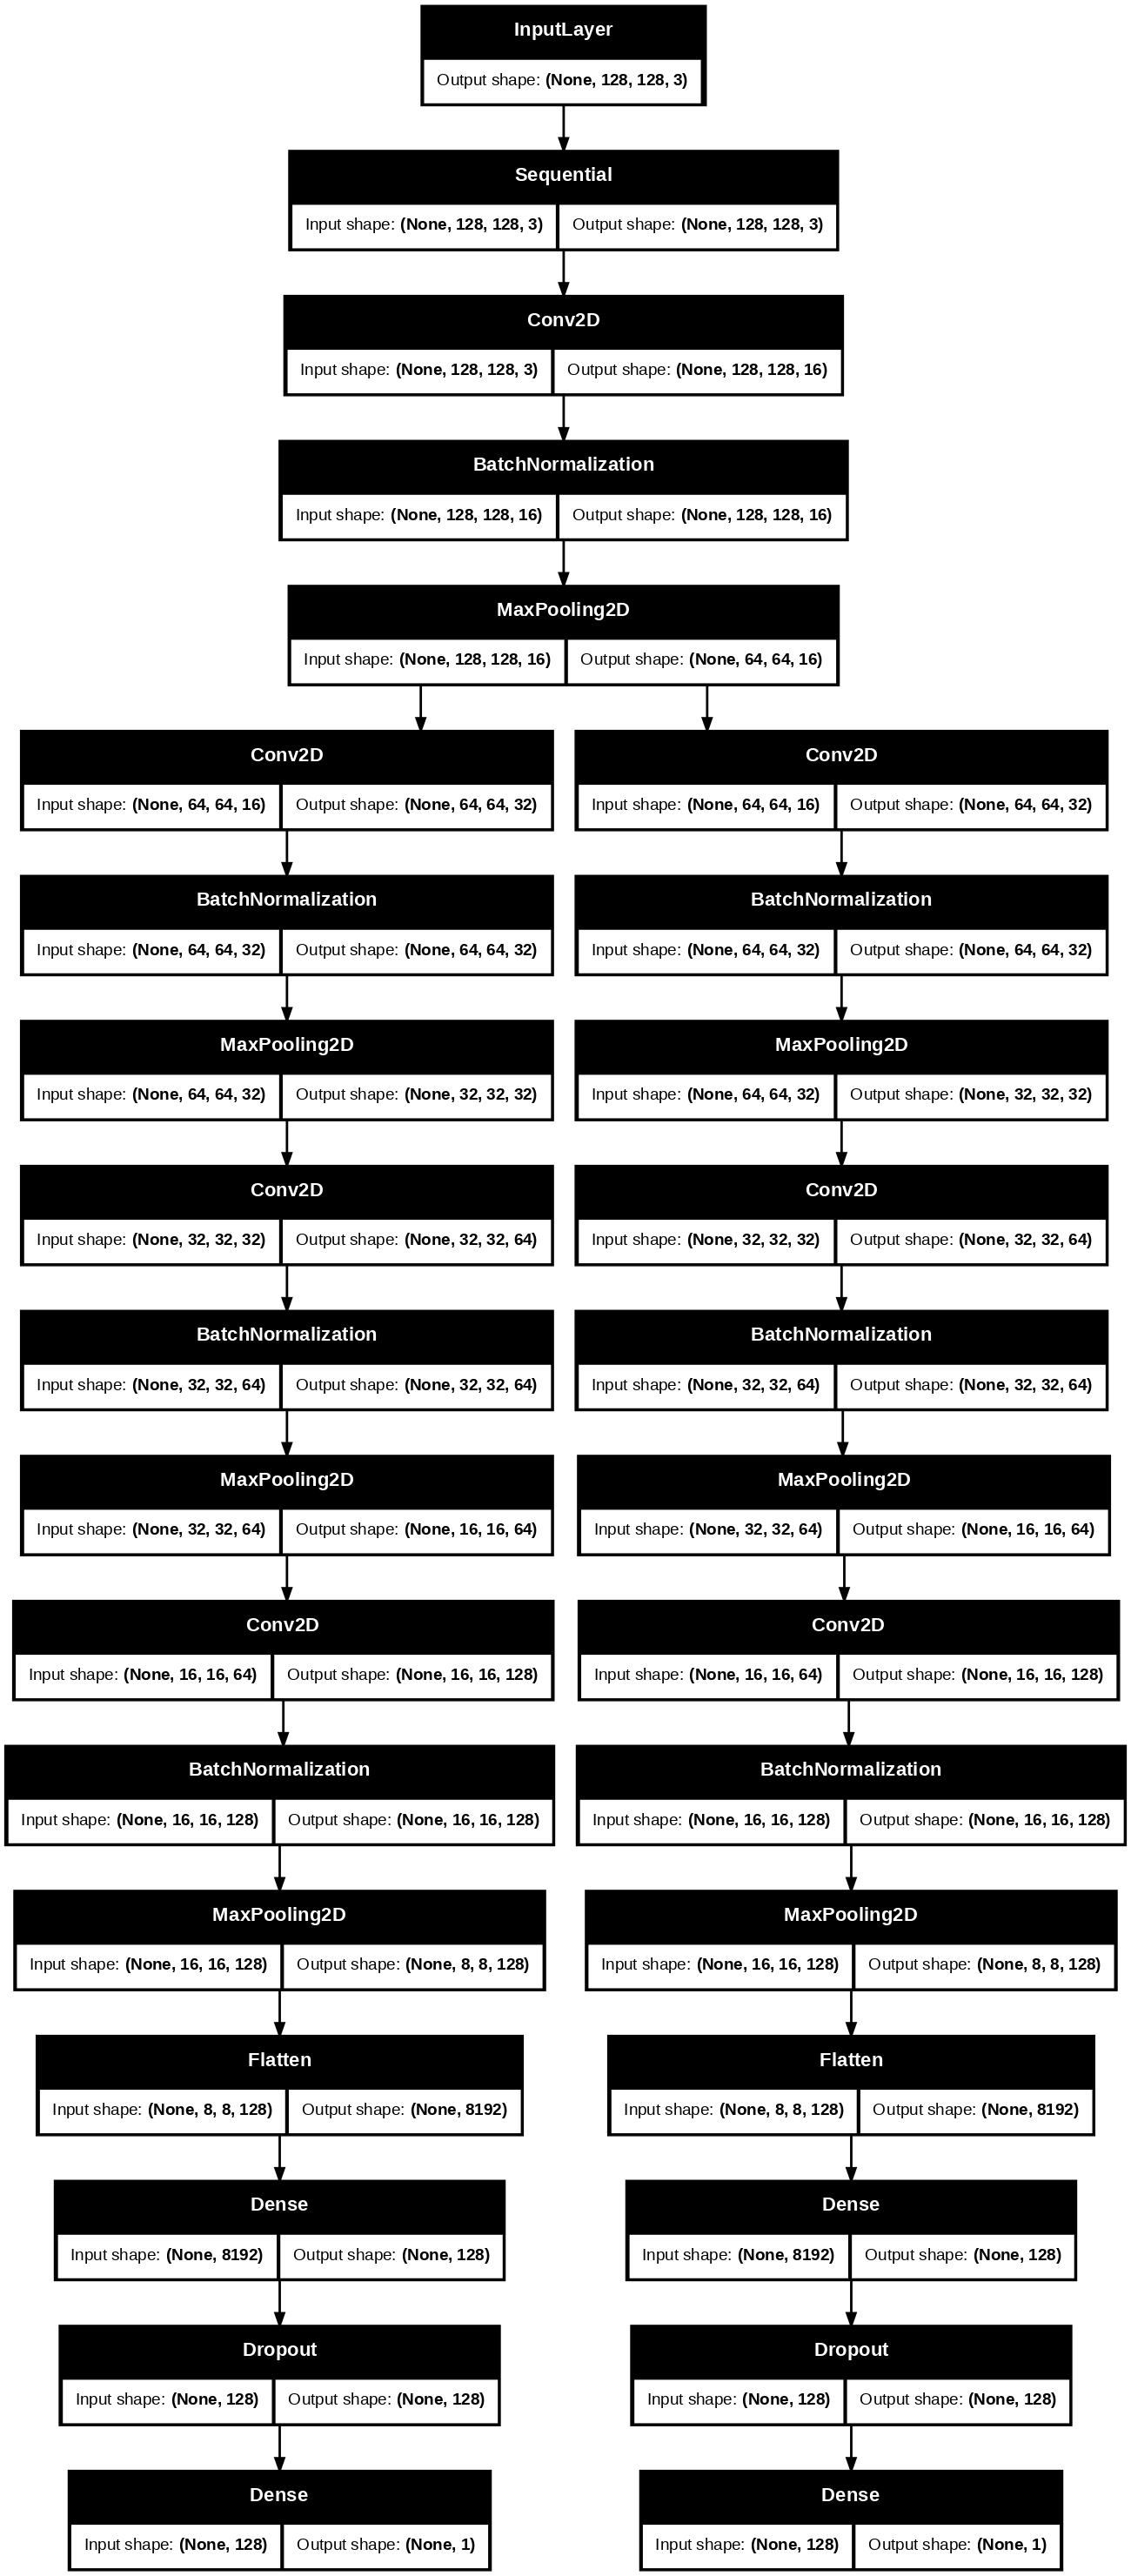

In [ ]:


inputs = layers.Input(shape=(128, 128, 3))

### shared layer
x = data_augmentation(inputs)
x = layers.Conv2D(16, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)


###split into two branches

### age branch
age_branch = layers.Conv2D(32, (3,3), padding='same',activation='relu')(x)
age_branch = layers.BatchNormalization()(age_branch)
age_branch = layers.MaxPooling2D((2,2))(age_branch)

age_branch = layers.Conv2D(64, (3,3),padding='same', activation='relu')(age_branch)
age_branch = layers.BatchNormalization()(age_branch)
age_branch = layers.MaxPooling2D((2,2))(age_branch)

age_branch = layers.Conv2D(128, (3,3), padding='same', activation='relu')(age_branch)
age_branch = layers.BatchNormalization()(age_branch)
age_branch = layers.MaxPooling2D((2,2))(age_branch)

age_branch = layers.Flatten()(age_branch)
age_branch = layers.Dense(128, activation='relu')(age_branch)
age_branch = layers.Dropout(0.5)(age_branch)

age_output = layers.Dense(1, activation='linear', name='age_output')(age_branch)

### gender branch
gender_branch = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
gender_branch = layers.BatchNormalization()(gender_branch)
gender_branch = layers.MaxPooling2D((2,2))(gender_branch)

gender_branch = layers.Conv2D(64, (3,3), padding='same', activation='relu')(gender_branch)
gender_branch = layers.BatchNormalization()(gender_branch)
gender_branch = layers.MaxPooling2D((2,2))(gender_branch)

gender_branch = layers.Conv2D(128, (3,3), padding='same', activation='relu')(gender_branch)
gender_branch = layers.BatchNormalization()(gender_branch)
gender_branch = layers.MaxPooling2D((2,2))(gender_branch)

gender_branch = layers.Flatten()(gender_branch)
gender_branch = layers.Dense(128, activation='relu')(gender_branch)
gender_branch = layers.Dropout(0.5)(gender_branch)

gender_output = layers.Dense(1, activation='sigmoid', name='gender_output')(gender_branch)


### define modelA
modelA = models.Model(
    inputs=inputs,
    outputs=[age_output, gender_output],
    name='modelA'
)

modelA.summary()
from tensorflow.keras.utils import plot_model
plot_model(modelA, show_shapes=True,dpi=100)

In [ ]:


optimizer = Adam(learning_rate=1e-3)

losses = {'age_output':tf.keras.losses.Huber(), 'gender_output':'binary_crossentropy'}  ### huber for age prediction | binary crossentropy for gender classification
loss_weights = {'age_output': 1.0,'gender_output':1.0}                 ### equal weight on both losses


###compile modelA
modelA.compile(
    optimizer = optimizer,
    loss=losses ,
    loss_weights=loss_weights,
    metrics={'age_output': ['mae'],'gender_output': ['accuracy'] }
)

### define LearningRateScheduler
def scheduler(epoch, lr):
    if epoch < 10 :
        return lr
    else:
        return lr * 0.9


early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True, verbose=1)  ### define early stopping
lr_callback = LearningRateScheduler(scheduler)


### train modelA
history = modelA.fit(
    train_images,
    {'age_output':train_age,'gender_output':train_gender},
    validation_data=(val_images, {'age_output':val_age, 'gender_output':val_gender}),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_callback],
    verbose=1
)


### performance on training and validarion sets
train_results_modelA = modelA.evaluate(
    train_images,
    {'age_output':train_age, 'gender_output':train_gender},
    verbose = 0
)

val_results_modelA = modelA.evaluate(
    val_images,
    {'age_output': val_age, 'gender_output': val_gender},
    verbose=0
)

print('Training Results')
print(f"Age MAE:{train_results_modelA[3]:.3f}")
print(f"Gender Accuracy.:{train_results_modelA[4]*100:.2f}%")
print()
print('Validation Results')
print(f"Age MAE:{val_results_modelA[3]:.3f}")
print(f"Gender Accuracy.:{val_results_modelA[4]*100:.2f}%")

modelA.save(folder_models+'age_gender_A.keras')

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - age_output_loss: 16.6804 - age_output_mae: 17.1735 - gender_output_accuracy: 0.6313 - gender_output_loss: 1.2797 - loss: 17.9601 - val_age_output_loss: 17.5358 - val_age_output_mae: 17.9911 - val_gender_output_accuracy: 0.4870 - val_gender_output_loss: 5.8221 - val_loss: 23.3870 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - age_output_loss: 13.6429 - age_output_mae: 14.1343 - gender_output_accuracy: 0.7342 - gender_output_loss: 0.5367 - loss: 14.1795 - val_age_output_loss: 12.2935 - val_age_output_mae: 12.7207 - val_gender_output_accuracy: 0.4920 - val_gender_output_loss: 2.1405 - val_loss: 14.3858 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - age_output_loss: 12.4435 - age_output_mae: 12.9345 - gender_output_accuracy: 0.7610 - gender_output_loss: 0.4839 - loss: 12.9274 - val_age_output_loss: 12.3716 - val_age_output_mae: 12.9154 - val_gender_output_accuracy: 0.7

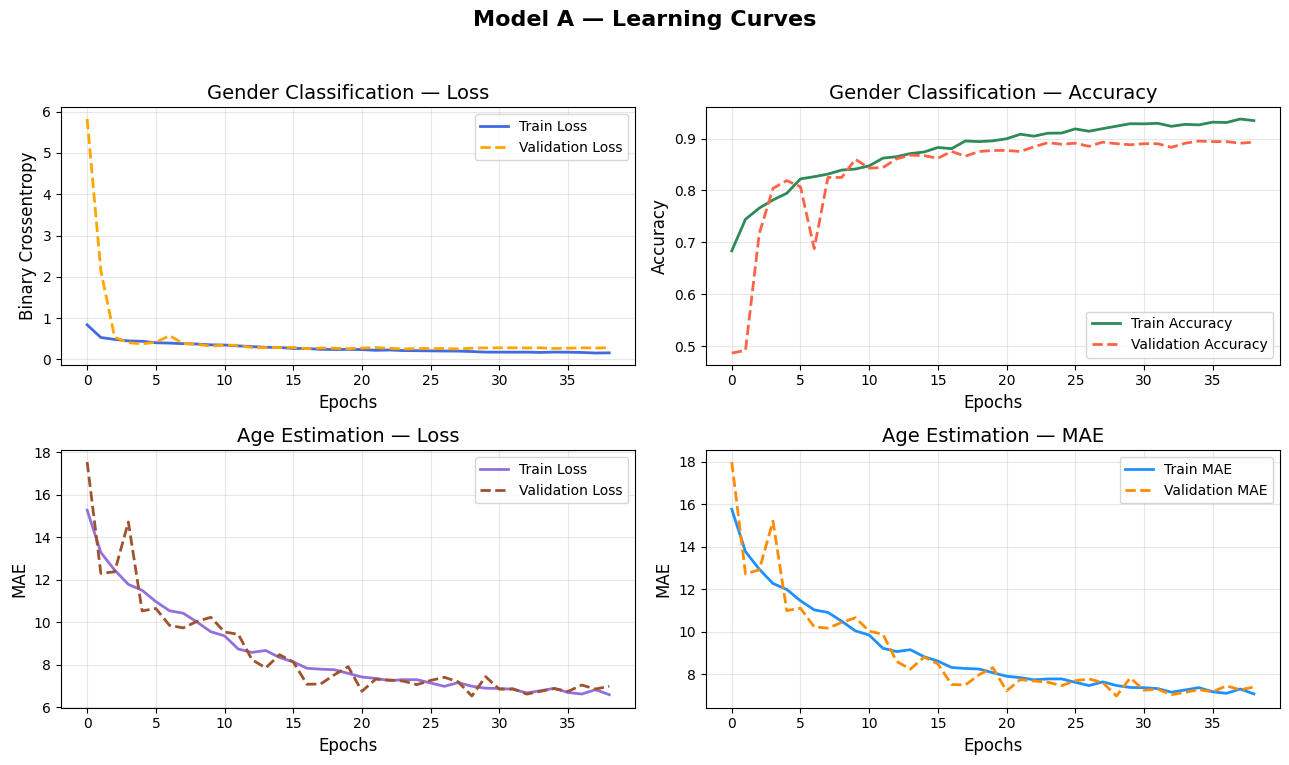

In [ ]:


plt.figure(figsize=(13, 8))
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'legend.fontsize': 10
})

### Gender classification | Loss
plt.subplot(2, 2, 1)
plt.plot(history.history['gender_output_loss'],color='royalblue', label='Train Loss')
plt.plot(history.history['val_gender_output_loss'], color='orange', linestyle='--',label='Validation Loss')
plt.title('Gender Classification — Loss')
plt.xlabel('Epochs' )
plt.ylabel('Binary Crossentropy' )
plt.legend()
plt.grid(alpha=0.3)

# Gender classification | Accuracy
plt.subplot(2, 2, 2)
plt.plot(history.history['gender_output_accuracy'], color='seagreen',label='Train Accuracy')
plt.plot(history.history['val_gender_output_accuracy'], color='tomato', linestyle='--', label='Validation Accuracy')
plt.title('Gender Classification — Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

### Age Estimation | Loss
plt.subplot(2, 2, 3)
plt.plot(history.history['age_output_loss'], color='mediumpurple', label='Train Loss')
plt.plot(history.history['val_age_output_loss'],color='sienna', linestyle='--', label='Validation Loss')
plt.title('Age Estimation — Loss')
plt.xlabel('Epochs' )
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)

### Age Estimation | MAE
plt.subplot(2, 2, 4)
plt.plot(history.history['age_output_mae'], color='dodgerblue', label='Train MAE' )
plt.plot(history.history['val_age_output_mae'], color='darkorange', linestyle='--', label='Validation MAE')
plt.title('Age Estimation — MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle('Model A — Learning Curves', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




#Model B - Pretrained model

Model: "ModelB_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bgr_to_rgb (Lambda) │ (None, 128, 128,  │          0 │ data_augmentatio… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescale_minus1_1    │ (None, 128, 128,  │          0 │ bgr_to_rgb[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 4, 4,      │  7,037,504 │ rescale_minus1_1… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    262,400 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        257 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        257 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,305,538 (27.87 MB)

 Trainable params: 265,474 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

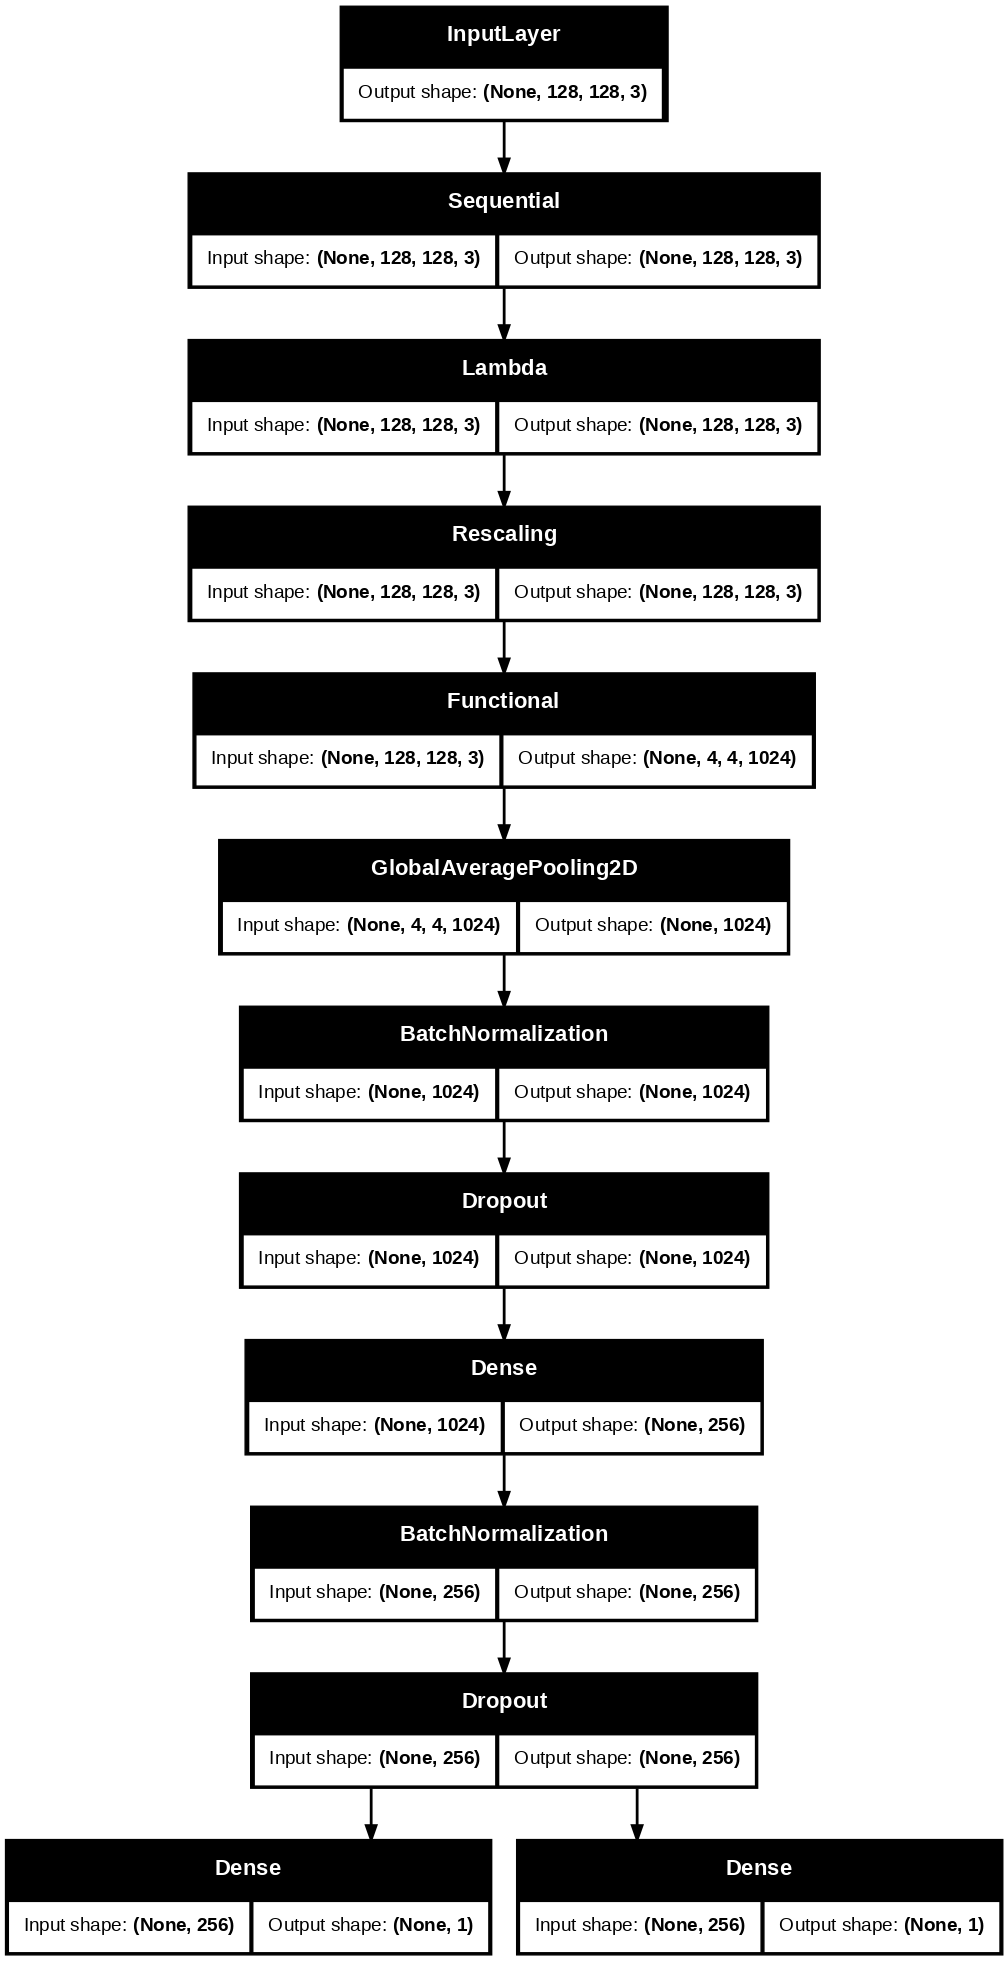

In [ ]:




inputs = layers.Input(shape=(128,128,3))
x = data_augmentation(inputs)
x = layers.Lambda(lambda t: t[..., ::-1], name="bgr_to_rgb")(x) ### converting BGR to RGB because images were loaded with cv2 library. DenseNet121 excepts RGB inputs
x = layers.Rescaling(2.0, offset=-1.0, name="rescale_minus1_1")(x) ### rescalling pixels from [0,1] to [-1,1] because DenseNet121 trained on this range


### DenseNet121 backbone
backbone = DenseNet121(include_top=False, weights="imagenet", input_shape=(128,128,3))
backbone.trainable = False ### freeze all layers

x = backbone(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)

### L2 regularization on Dense layer
x = layers.Dense(256, activation="relu",kernel_regularizer=regularizers.l2(1e-4))(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

age_output = layers.Dense(1, activation="linear", name="age_output")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender_output")(x)

modelB = models.Model(inputs, [age_output, gender_output], name="ModelB_DenseNet121")

modelB.summary()
from tensorflow.keras.utils import plot_model
plot_model(modelB, show_shapes=True,dpi=100)

In [ ]:



losses = {'age_output':'mae' ,'gender_output':tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)} ### mae for age prediction and binary crossentropy for gender classification
loss_weights = {'age_output': 1.0,'gender_output':1.0} ### equal weights
metrics = {'age_output': ['mae'],'gender_output':['accuracy']} ### MAE for age | accuracy for gender


### compile model B with Adam optimizer
modelB.compile(
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-5),
    loss=losses ,
    loss_weights=loss_weights,
    metrics=metrics
)


early_stop_1 = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr_1  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# phase 1 | train with backbone being frozen
history_B1 = modelB.fit(
    train_images,
    {'age_output':train_age,'gender_output':train_gender},
    validation_data=(val_images,{'age_output': val_age,'gender_output':val_gender}),
    epochs= 15,
    batch_size=32,
    callbacks=[early_stop_1, reduce_lr_1],
    verbose=1
)

# fine-tuning phase | unfreeze the last 250 layers
for layer in backbone.layers[-250:]:
    layer.trainable = True

optimizer =AdamW(learning_rate=5e-5,weight_decay=1e-5)

### now compile with lower learning rate
modelB.compile(
    optimizer=optimizer,
    loss=losses,
    loss_weights={'age_output':1.0, 'gender_output':1.0},
    metrics=metrics
)


### new callbacks
early_stop_2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_2  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

### continue training
history_B2 = modelB.fit(
    train_images,
    {'age_output':train_age, 'gender_output':train_gender},
    validation_data=(val_images, {'age_output':val_age, 'gender_output':val_gender}),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop_2, reduce_lr_2],
    verbose=1
)



### performance on training and validation set

train_results_modelB = modelB.evaluate(train_images, {'age_output':train_age, 'gender_output':train_gender}, verbose=1)
print(f"Training Age MAE : {train_results_modelB[3]:.2f}")
print(f"Training Gender Accuracy : {train_results_modelB[4]*100:.2f}%")


val_results_modelB = modelB.evaluate(val_images, {'age_output':val_age, 'gender_output':val_gender}, verbose=1)
print(f"\nValidation Age MAE : {val_results_modelB[3]:.2f}")
print(f"Validation Gender Accuracy : {val_results_modelB[4]*100:.2f}%")

modelB.save(your_model_folder+"age_gender_B.keras")

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 118ms/step - age_output_loss: 32.5758 - age_output_mae: 32.5758 - gender_output_accuracy: 0.7076 - gender_output_loss: 0.6413 - loss: 33.2578 - val_age_output_loss: 32.7072 - val_age_output_mae: 32.6123 - val_gender_output_accuracy: 0.8170 - val_gender_output_loss: 0.4537 - val_loss: 33.1028 - learning_rate: 3.0000e-04
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - age_output_loss: 31.6828 - age_output_mae: 31.6828 - gender_output_accuracy: 0.7962 - gender_output_loss: 0.4905 - loss: 32.2123 - val_age_output_loss: 31.2811 - val_age_output_mae: 31.1816 - val_gender_output_accuracy: 0.8400 - val_gender_output_loss: 0.4130 - val_loss: 31.6303 - learning_rate: 3.0000e-04
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - age_output_loss: 30.2148 - age_output_mae: 30.2148 - gender_output_accuracy: 0.8077 - gender_output_loss: 0.4671 - loss: 30.7200 - val_age_output_loss: 28.3453 - val_age_output_mae: 28.2168 - val_gender_output_accurac

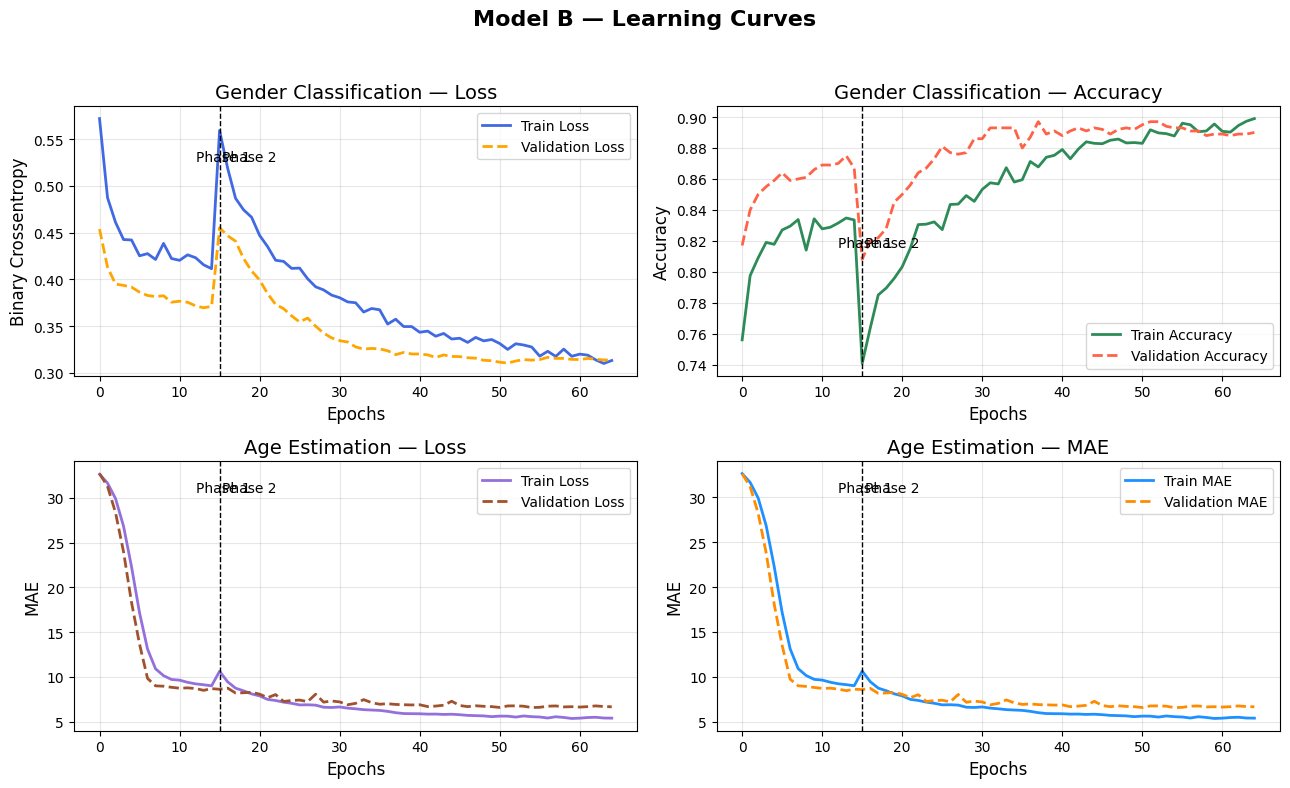

In [ ]:


### combine thw two training phases
def merge_histories(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key]+ h2.history[key]
    return history


history_B =merge_histories(history_B1, history_B2)

phase_split =len(history_B1.history[ 'loss'])


plt.figure(figsize=(13,8))
plt.rcParams.update({
    'axes.titlesize':14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'legend.fontsize':10
})


### gender classification | loss
plt.subplot(2, 2, 1)
plt.plot(history_B['gender_output_loss'],color='royalblue', label='Train Loss')
plt.plot(history_B['val_gender_output_loss'], color='orange', linestyle='--', label='Validation Loss')
plt.axvline(x=phase_split, color='black', linestyle='--', linewidth=1)
plt.text(phase_split+ 0.3, plt.ylim()[1] * 0.9, "Phase 2", fontsize=10)
plt.text(phase_split - 3,plt.ylim()[1] * 0.9, "Phase 1", fontsize=10)
plt.title('Gender Classification — Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(alpha=0.3 )


### gender classification | accuracy
plt.subplot(2, 2, 2)
plt.plot(history_B['gender_output_accuracy'], color='seagreen', label='Train Accuracy')
plt.plot(history_B['val_gender_output_accuracy'], color='tomato', linestyle='--', label='Validation Accuracy')
plt.axvline(x=phase_split, color='black', linestyle='--', linewidth=1)
plt.text(phase_split + 0.3, plt.ylim()[1]* 0.9, "Phase 2", fontsize=10)
plt.text(phase_split - 3, plt.ylim()[1] * 0.9, "Phase 1", fontsize=10)
plt.title('Gender Classification — Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)


### age estimation | loss
plt.subplot(2, 2, 3)
plt.plot(history_B['age_output_loss'], color='mediumpurple', label='Train Loss')
plt.plot(history_B['val_age_output_loss'], color='sienna', linestyle='--',label='Validation Loss')
plt.axvline(x=phase_split, color='black', linestyle='--',linewidth=1)
plt.text(phase_split + 0.3, plt.ylim()[1]* 0.9,"Phase 2", fontsize=10)
plt.text(phase_split - 3, plt.ylim()[1] * 0.9, "Phase 1", fontsize=10)
plt.title('Age Estimation — Loss')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)


### age estimation | MAE
plt.subplot(2, 2, 4)
plt.plot(history_B['age_output_mae'], color='dodgerblue', label='Train MAE')
plt.plot(history_B['val_age_output_mae'], color='darkorange', linestyle='--', label='Validation MAE')
plt.axvline(x=phase_split, color='black', linestyle='--', linewidth=1)
plt.text(phase_split + 0.3, plt.ylim()[1] * 0.9, "Phase 2", fontsize=10)
plt.text(phase_split - 3, plt.ylim()[1] * 0.9, "Phase 1", fontsize=10)
plt.title('Age Estimation — MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle('Model B — Learning Curves',fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0,0, 1,0.95])
plt.savefig("learning_curves_modelB.png",bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()